In [1]:
import sys
import os
import pandas as pd
import numpy as np
import torch
import copy
import pandas as pd
import torch
import yaml
from enviroment import Stock_Env
from agent import PPO
from grpo import test_grpo

Current working directory: /workspace/portfolio_price_discrete_v4_small_filter


In [51]:


def set_seed(seed):
    # random.seed(seed)
    # np.random.seed(seed)
    torch.manual_seed(seed)
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False
    print(f"Random seed set to: {seed}")

SEED = 42
set_seed(SEED)

with open("./config/test_config.yaml", "r") as f:
    config = yaml.safe_load(f)
    

index_train_path = "../data/train_v3.csv"
index_test_path = "../data/test_v3.csv"
future_train_path = "../data/future_train_v3.csv"
future_test_path = "../data/future_test_v3.csv"
test_pt = "../data/portfolio_price/portfolio_test_v3.pt"



device = torch.device(config.get("device", "cuda:0"))
config["device"] = device

index_train_for_valid = pd.read_csv(index_train_path, index_col=0)
index_test_df = pd.read_csv(index_test_path, index_col=0)

index_test_all_df = pd.concat([index_train_for_valid, index_test_df], axis=0)
index_test_all_df.reset_index(drop=True, inplace=True)
index_test_all_df.set_index("date", inplace=True)

future_train_for_valid = pd.read_csv(future_train_path, index_col=0)
future_test_df = pd.read_csv(future_test_path, index_col=0)
future_test_all_df = pd.concat([future_train_for_valid, future_test_df], axis=0)
future_test_all_df.reset_index(drop=True, inplace=True)
future_test_all_df.set_index("date", inplace=True)


test_tensor = torch.load(test_pt, map_location=device)
traj_len ="1m"
update_interval = config["update_interval_map"].get(traj_len, 60)
config["update_interval"] = update_interval
config["batch_samples"] = config["batch_samples"].get(traj_len, 5)
config["TRADE_START_DATE"] = "2019-01-01"
config["TRADE_END_DATE"] = "2024-12-31"
env = Stock_Env(config=config, states=test_tensor, index_df=index_test_all_df, future_df = future_test_all_df, eval=True)


agent = PPO(env, eval=True)
model_path =  "./model/5d/final_5d_actor_lr1e-05_clip_grad1_epslion_0.1batch_sample_256_mu50_num_group128_num_steps10_reward_cond_sharpe_grpo_model.pth"
agent.load(model_path)
model_return, strategy_returns, weight_rebal, strategy_weights = test_grpo(env, agent)

Random seed set to: 42


/tmp/ipykernel_650649/510653774.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_tensor = torch.load(test_pt, map_location=device)
/workspace/portfolio_price_discre

./model/5d/final_5d_actor_lr1e-05_clip_grad1_epslion_0.1batch_sample_256_mu50_num_group128_num_steps10_reward_cond_sharpe_grpo_model.pth loaded.


/opt/conda/lib/python3.11/site-packages/cvxpy/problems/problem.py:1504: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
최적화 실패. 균등 포트폴리오로 fallback.
Day: 2019-01-02 ~ 2019-01-30
Day: 2019-01-31 ~ 2019-02-28
Day: 2019-03-01 ~ 2019-03-28
Day: 2019-03-29 ~ 2019-04-26
Day: 2019-04-29 ~ 2019-05-24
Day: 2019-05-28 ~ 2019-06-24
Day: 2019-06-25 ~ 2019-07-23
Day: 2019-07-24 ~ 2019-08-20
Day: 2019-08-21 ~ 2019-09-18
Day: 2019-09-19 ~ 2019-10-16
Day: 2019-10-17 ~ 2019-11-13
Day: 2019-11-14 ~ 2019-12-12
Day: 2019-12-13 ~ 2020-01-13
Day: 2020-01-14 ~ 2020-02-11
Day: 2020-02-12 ~ 2020-03-11
Day: 2020-03-12 ~ 2020-04-08
Day: 2020-04-09 ~ 2020-05-07
Day: 2020-05-08 ~ 2020-06-05
Day: 2020-06-08 ~ 2020-07-06
Day: 2020-07-07 ~ 2020-08-03
Day: 2020-08-04 ~ 2020-08-31
Day: 2020-09-01 ~ 2020-09-29
Day: 2020-09-30 ~ 2020-10-27
Day: 2020-10-28 ~ 2020-11-24
Day: 2020-11-25 ~ 2020-12-23
Day: 2020-12-24 ~ 2021-01-25
Day: 2021-01-26 ~ 2021

In [41]:


# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 42
# set_seed(SEED)

# with open("./config/test_config.yaml", "r") as f:
#     config = yaml.safe_load(f)
    
# train_data_path = "../data/train_v2.csv"
# test_data_path = "../data/test_v2.csv"
# test_pt = "../data/portfolio_price/portfolio_test.pt"

# device = torch.device(config.get("device", "cuda:0"))
# config["device"] = device

# train_df = pd.read_csv(train_data_path, index_col=0)
# test_df = pd.read_csv(test_data_path, index_col=0)
# test_all_df = pd.concat([train_df, test_df], axis=0)
# test_all_df.reset_index(drop=True, inplace=True)
# test_all_df.set_index("date", inplace=True)

# test_tensor = torch.load(test_pt, map_location=device)
# traj_len ="1m"
# update_interval = config["update_interval_map"].get(traj_len, 60)
# config["update_interval"] = update_interval
# config["batch_samples"] = config["batch_samples"].get(traj_len, 5)
# config["TRADE_START_DATE"] = "2017-01-03"
# config["TRADE_END_DATE"] = "2019-12-31"
# config["data_paths"]["portfolio_path"] = "../data/portfolio_price/test_portfolio_price.csv"

# env = Stock_Env(config=config, states=test_tensor, real_df=test_all_df, eval=True)
# agent = PPO(env, eval=True)
# model_path =  "./model/5d/final_5d_actor_lr1e-06_clip_grad1_epslion_0.1batch_sample_256_mu50_num_group128_num_steps10_reward_cond_sharpe_grpo_model.pth"
# agent.load(model_path)
# model_return, strategy_returns, weight_rebal, strategy_weights = test_grpo(env, agent)

In [42]:
# def set_seed(seed):
#     # random.seed(seed)
#     # np.random.seed(seed)
#     torch.manual_seed(seed)
#     # torch.cuda.manual_seed(seed)
#     # torch.cuda.manual_seed_all(seed)  # Multi-GPU 환경 고려
#     # torch.backends.cudnn.deterministic = True
#     # torch.backends.cudnn.benchmark = False
#     print(f"Random seed set to: {seed}")

# SEED = 50
# set_seed(SEED)

# with open("./config/test_config.yaml", "r") as f:
#     config = yaml.safe_load(f)
    
# train_data_path = "../data/train_v1.csv"
# test_data_path = "../data/test_v1.csv"
# test_pt = "../data/no_tran_test_tensor_dict_v2.pt"

# device = torch.device(config.get("device", "cuda:0"))
# config["device"] = device

# train_df = pd.read_csv(train_data_path, index_col=0)
# test_df = pd.read_csv(test_data_path, index_col=0)
# test_all_df = pd.concat([train_df, test_df], axis=0)
# test_all_df.reset_index(drop=True, inplace=True)
# test_all_df.set_index("date", inplace=True)

# test_tensor = torch.load(test_pt, map_location=device)
# traj_len ="1m"
# update_interval = config["update_interval_map"].get(traj_len, 60)
# config["update_interval"] = update_interval
# config["batch_samples"] = config["batch_samples"].get(traj_len, 5)
# env = Stock_Env(config=config, states=test_tensor, real_df=test_all_df, eval=True)
# agent = PPO(env, eval=True)
# model_path =  "model/5d/5d_actor_lr1e-06_clip_grad1_epslion_0.1beta0_mu50_num_group128_num_steps10_reward_cond_sharpe_grpo_model.pth"
# agent.load(model_path)
# model_return, strategy_returns, weight_rebal = test_grpo(env, agent)

In [43]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# def plot_weight_heatmap(weight_df, strategy_name='Strategy', cmap='coolwarm'):
#     """
#     자산별 시점별 weight를 히트맵으로 시각화하는 함수
    
#     Parameters:
#     - weight_df: (DataFrame) index=date, columns=assets, values=weights
#     - strategy_name: (str) 전략 이름 (default: 'Strategy')
#     - cmap: (str) 사용할 colormap 이름 (default: 'coolwarm')
#     """
#     fig, ax = plt.subplots(figsize=(16, 8))

#     sns.heatmap(
#         weight_df.T,
#         cmap=cmap,
#         cbar=True,
#         linewidths=0.5,
#         linecolor='lightgray',
#         ax=ax,
#         center=weight_df.mean().mean()  # 중앙 기준 색상 설정
#     )

#     # ✅ 제목 자동 생성
#     ax.set_title(f'{strategy_name} Weights Over Time', fontsize=18)
#     ax.set_xlabel('Date', fontsize=14)
#     ax.set_ylabel('Assets', fontsize=14)

#     # x축 날짜 표시 조정
#     step = max(1, len(weight_df.index) // 20)
#     selected_ticks = weight_df.index[::step]

#     ax.set_xticks(range(0, len(weight_df.index), step))
#     ax.set_xticklabels(selected_ticks, rotation=45, ha='right')

#     # y축 자산 이름 정렬
#     ax.set_yticklabels(weight_df.columns, rotation=0)

#     plt.tight_layout()
#     plt.show()
# rp_weight = strategy_weights["GTAA"].iloc[::20]
# plot_weight_heatmap(rp_weight, strategy_name="GTAA", cmap='YlGnBu')


In [52]:
strategy_weights.keys()

dict_keys(['future_risk', 'index_risk', 'future_minvar', 'index_minvar', 'future_ms', 'index_ms', 'future_paa', 'index_paa', 'equal'])

In [53]:
model_return.rename(columns={0: "Model"}, inplace=True)

In [54]:
strategy_returns["Model"] = model_return["Model"]

In [55]:
def calculate_annual_return(returns, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    cumulative = np.prod(1 + returns)
    n_periods = len(returns)
    return cumulative ** (annual_factor / n_periods) - 1


def calculate_max_drawdown(returns):
    returns = np.array(returns, dtype=np.float64)
    cumulative_returns = np.cumprod(1 + returns)
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdowns = (cumulative_returns - running_max) / running_max
    return abs(np.min(drawdowns))

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=12):
#     returns = np.array(returns, dtype=np.float64)
#     geo_return = np.prod(1 + returns) ** (1 / len(returns)) - 1
#     risk_free_rate /= annual_factor
#     excess_geo_return = geo_return - risk_free_rate
#     std_dev = np.std(returns, ddof=1)
#     return (excess_geo_return * annual_factor) / (std_dev * np.sqrt(annual_factor)) if std_dev != 0 else 0.0

def calculate_sharpe_ratio(returns, risk_free_rate=0.02, annual_factor=252):
    returns = np.array(returns, dtype=np.float64)
    annual_return = calculate_annual_return(returns, annual_factor)
    annual_std_dev = calculate_volatility(returns, annual_factor)
    excess_return =  (annual_return - risk_free_rate) 
    # 연환산 수익률과 표준편차
    return excess_return / annual_std_dev if annual_std_dev != 0 else 0.0


def calculate_cumulative_return(returns):
    returns = np.array(returns, dtype=np.float64)
    return np.prod(1 + returns) - 1

def calculate_volatility(returns, annual_factor=252):
    returns = np.asarray(returns)
    return np.std(returns, ddof=1) * np.sqrt(annual_factor)


# 성과 지표 계산 함수 (파라미터화)
def calculate_performance_metrics(returns, annual_factor=252, risk_free_rate=0.0):
    cumulative_returns = (1 + returns).cumprod()
    # cagr = calculate_cagr(returns, annual_factor)
    annual_return = calculate_annual_return(returns, annual_factor)
    sharpe_ratio = calculate_sharpe_ratio(returns, risk_free_rate, annual_factor)
    mdd = calculate_max_drawdown(returns)
    volatility = calculate_volatility(returns, annual_factor)

    return {
        'Cumulative Return': cumulative_returns.iloc[-1] - 1,
        'Annual Return': annual_return,
        # 'CAGR': cagr,
        'Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'MDD': mdd
    }


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


# 성과 지표 요약 생성 함수 (파라미터 전달)
def get_performance_summary(returns_dict, annual_factor=252, risk_free_rate=0.0):
    metrics_df = pd.DataFrame()
    for name, returns in returns_dict.items():
        metrics_df[name] = calculate_performance_metrics(returns, annual_factor, risk_free_rate)
    return metrics_df.T


import matplotlib.pyplot as plt
import numpy as np




In [56]:
def plot_cumulative_returns(returns_dict, title='Cumulative Returns', y_range=(0.0, 5), test_start_date=None):
    plt.figure(figsize=(14, 8))

    # 전략별 색깔 테이블 (고정)
    color_map = {
        'rp': 'skyblue',
        'min_var': 'darkorange',
        'mean_var_max_sharpe': 'limegreen',
        'daa': 'crimson',
        'paa': 'purple',
        'gtaa': 'sienna',
        'equal': 'black',
        'equal weight': 'black',
        'model': '#4169E1', 
    }

    for strategy_name, daily_returns in returns_dict.items():
        cumulative_returns = (1 + daily_returns).cumprod()
        
        lower_name = strategy_name.lower()
        color = color_map.get(lower_name, None)

        if color:
            plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
                     label=f'Strategy - {strategy_name}', color=color, linewidth=2.5 if lower_name in ['equal', 'equal weight', 'model'] else 1.8)
        else:
            plt.plot(cumulative_returns.index.astype(str), cumulative_returns.values,
                     label=f'Strategy - {strategy_name}', linewidth=1.5)

    if test_start_date:
        plt.axvline(x=test_start_date, color='red', linestyle='--', linewidth=2, label='Test Start')

    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.ylim(y_range)
    plt.xticks(np.arange(0, len(cumulative_returns.index), 60),
               cumulative_returns.index.astype(str)[::60], rotation=45)
    plt.legend(loc='upper left', fontsize='small', ncol=2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

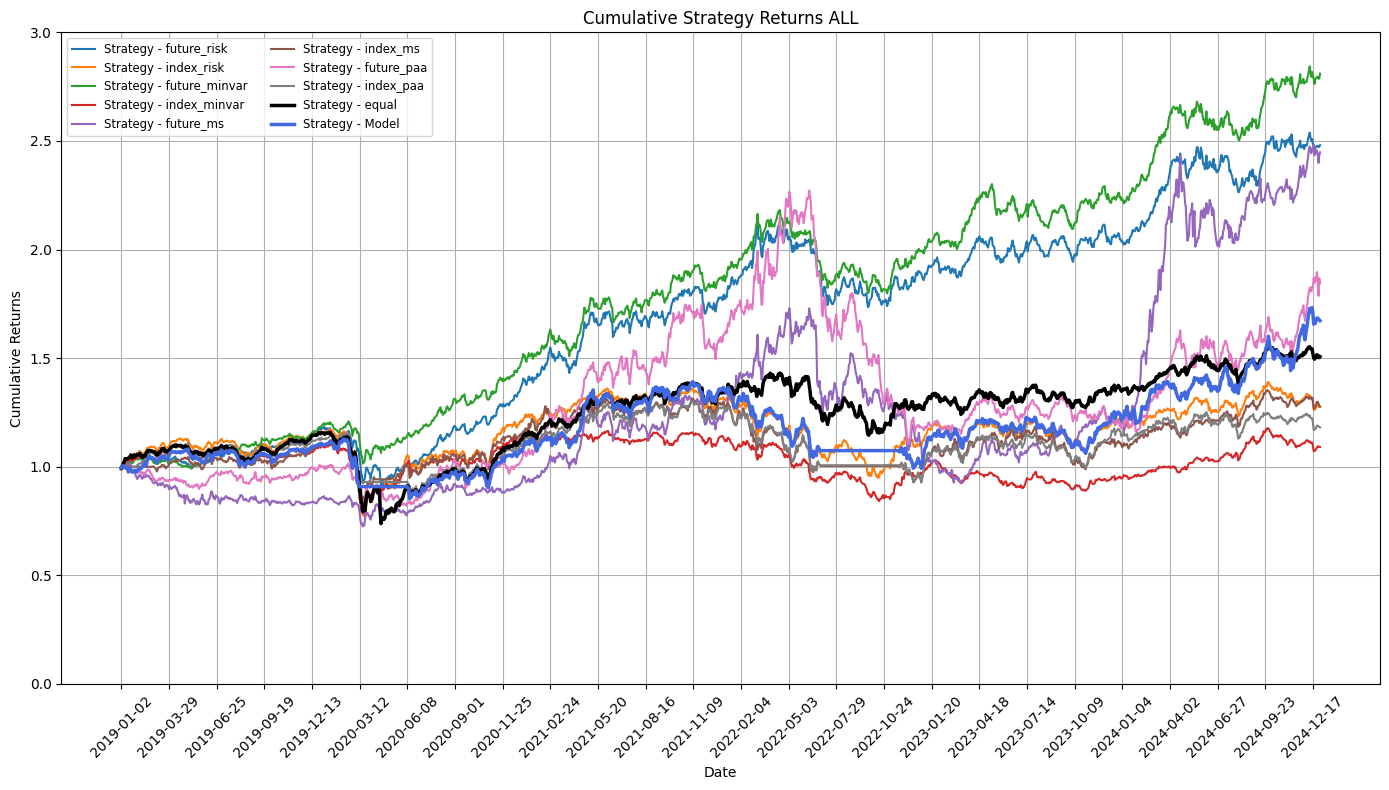

In [57]:
plot_cumulative_returns(strategy_returns, "Cumulative Strategy Returns ALL", (0.0, 3))

In [20]:
RP = pd.DataFrame(strategy_returns["RP"], columns=["RP"])
Model = pd.DataFrame(strategy_returns["Model"], columns=["Model"])
GTAA = pd.DataFrame(strategy_returns["GTAA"], columns=["GTAA"])


KeyError: 'RP'

In [21]:
# rp_test = RP.loc["2022-08-24":"2023-11-02"]
# Model_test = Model.loc["2022-08-24":"2023-11-02"]
# gtaa_test = GTAA.loc["2022-08-24":"2023-11-02"]

In [13]:
metrics_summary = get_performance_summary(
    strategy_returns,
    annual_factor=252,
    risk_free_rate=0.0
)

display(metrics_summary)


,Cumulative Return,Annual Return,Volatility,Sharpe Ratio,MDD
future_risk,1.481170,0.163759,0.135278,1.210539,0.233582
index_risk,0.274334,0.041287,0.159195,0.259349,0.350022
future_minvar,1.809858,0.188173,0.118635,1.586152,0.176238
index_minvar,0.091041,0.014648,0.121338,0.120717,0.292026
future_ms,1.447418,0.161102,0.232399,0.693214,0.465971
index_ms,0.277859,0.041767,0.164069,0.254571,0.294683
future_paa,0.844737,0.107595,0.219106,0.491065,0.513095
index_paa,0.181184,0.028179,0.145184,0.194093,0.286628
equal,0.507161,0.070860,0.151195,0.468664,0.363214
Model,0.765044,0.099462,0.217387,0.457537,0.513095


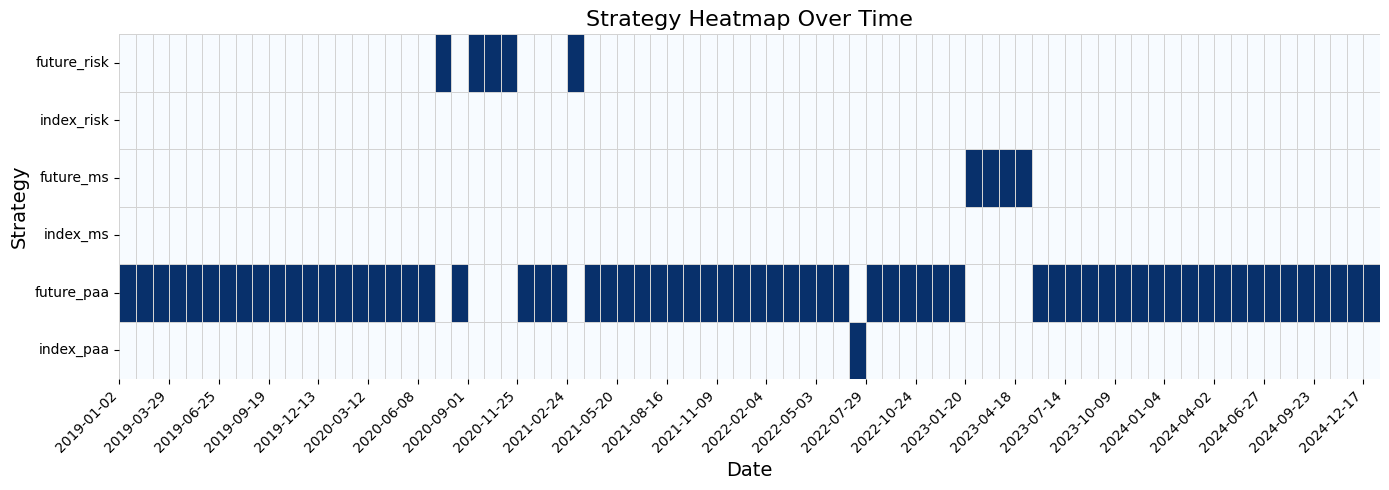

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

dominant_one_hot = pd.get_dummies(weight_rebal.idxmax(axis=1))

all_strategies = weight_rebal.columns
dominant_one_hot = dominant_one_hot.reindex(columns=all_strategies, fill_value=0).astype(float)


# Heatmap 그리기
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    dominant_one_hot.T,
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='lightgray',
    ax=ax
)

# 제목과 축 레이블 설정
ax.set_title('Strategy Heatmap Over Time', fontsize=16)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Strategy', fontsize=14)

# x축 날짜 포맷팅
step = max(1, len(weight_rebal.index) // 20)
selected_ticks = weight_rebal.index[::step]

ax.set_xticks(range(0, len(weight_rebal.index), step))
ax.set_xticklabels(selected_ticks, rotation=45, ha='right')

# y축 전략 이름 정렬
ax.set_yticklabels(all_strategies, rotation=0)

plt.tight_layout()
plt.show()
